In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.ipc as ipc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
import scipy.cluster.hierarchy as hierarchy
from scipy.spatial.distance import pdist, squareform
import sys
import importlib

# python source path
sys.path.append('../Src/')

# custom python 
import zscore_anomaly
import hierarchy_clustering
import utils
import plot

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Scipy": scipy.__version__
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)
# reset options
# pd.reset_option('display.max_columns')

# Use a single Arrow string & int64 type instance to save memory
arrow_string = pd.ArrowDtype(pa.string())
arrow_int64 = pd.ArrowDtype(pa.int64())
arrow_bool = pd.ArrowDtype(pa.bool8())

  Library Version
0  Python  3.13.9
1  Pandas   2.3.3
2   NumPy   2.3.4
3   Scipy  1.16.3


In [2]:
# Read Arrow IPC file
with open('../Data/crime_data.arrow', 'rb') as f:
    reader = ipc.open_file(f)
    table = reader.read_all()
    
# Convert back to pandas (Arrow‑backed)
df = table.to_pandas(types_mapper=pd.ArrowDtype)
# Display
df.head()

,date,description,location_description,arrest,domestic,beat,district,ward,community_code,year,zip_code,zip_code_area,neighborhood,neighborhood_area,community_name,community_area,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,sector
0,2001-12-30 02:30:00,AUTOMOBILE,STREET,0,0,334,003,07,43,2001,60649,80526075.8505,South Shore,81812716.3904,South Shore,81812716.3958,December,Sunday,Q4,2001-Q4,Late Night,Motor Vehicle Theft,1,Grand Crossing,1
1,2001-12-24 12:30:00,FRAUD OR CONFIDENCE GAME,APARTMENT,0,0,2313,019,46,03,2001,60640,77305245.6358,Uptown,65095642.836,Uptown,65095642.7289,December,Monday,Q4,2001-Q4,Afternoon,Fraud,0,Town Hall,3
2,2001-12-31 23:00:00,FINANCIAL ID THEFT:$300 &UNDER,APARTMENT,0,0,1531,015,37,25,2001,60651,99039621.5713,Austin,170037750.826,Austin,199254203.427,December,Monday,Q4,2001-Q4,Night,Larceny – Theft,1,Austin,4
3,2001-12-23 22:30:00,AUTOMOBILE,STREET,0,0,1022,010,12,30,2001,60623,155285530.844,Little Village,127998297.819,South Lawndale,127998297.867,December,Sunday,Q4,2001-Q4,Night,Motor Vehicle Theft,1,Ogden,4
4,2001-12-31 20:00:00,PREDATORY,APARTMENT,0,0,1723,017,33,14,2001,60625,105830918.044,Albany Park,53542230.819,Albany Park,53542230.8191,December,Monday,Q4,2001-Q4,Night,Criminal Sexual Assault,1,Albany Park,5


In [3]:
# NaNs
utils.any_nans(df)

--- Missing Values Found (Total Rows: 8,469,872) ---
                       Count Percentage
neighborhood_area     116237    1.3724%
community_area        116237    1.3724%
zip_code_area         116181    1.3717%
ward                   84100    0.9929%
location_description   15338    0.1811%
community_code          9744    0.1150%
zip_code                9744    0.1150%
neighborhood            9744    0.1150%
community_name          9744    0.1150%
district                 139    0.0016%
district_location        139    0.0016%
sector                   139    0.0016%


#### Calculating the Z-score highlights specialized anomalies
- A Z-score of 3.0
    - The value is higher than about 99.87% of all values in a normal distribution 
    - It’s an extreme outlier
- A Z‑score of 2 means:
    - The value is higher than about 97.7% of all values in a normal distribution
    - That year’s count is significantly higher than the historical average
- A Z-score of -1:
    - The value is lower than about 84% of all values
    - It’s a mild decrease, not extreme

##### User Function(s)

In [4]:
def heat_map(data: pd.DataFrame, typ: str='Indexed', figsize: tuple=(16, 6)) -> None:
    # Create the Heatmap
    plt.figure(figsize=figsize)
    sns. heatmap(
        data,
        cmap="RdBu_r",          # Red for high Z-scores, Blue for low
        center=0,               # White represents the mean
        annot=True,             # Change to False if you don't want to see the numbers
        fmt=".2f",              # format as integers
        annot_kws={"size": 8}, # change font size here
        linewidths=.5
    )
    plt.title(f"Z‑Score Heatmap ({typ} Crimes)", fontsize=16)
    plt.xlabel("Year", fontsize=10)
    plt.ylabel("Crime Type", fontsize=12)
    plt.yticks(fontsize=10, rotation=0, ha='right')
    plt.xticks(fontsize=10, rotation=45, ha='right')
    plt.show()


def linkage_matrix(data: pd.DataFrame, method: str, metric: str):
    """
    Compute the linkage matrix for hierarchical clustering.

    Parameters:
    - data: pd.DataFrame, rows as observations, columns as features
    - method: str, linkage method ('single', 'complete', 'average', 'ward', etc.)
    - metric: str, distance metric ('euclidean', 'correlation', etc.)

    Returns:
    - Z: linkage matrix
    """
    Z = hierarchy.linkage(data.values, method=method, metric=metric, optimal_ordering=True)
    return Z



def plot_clustering(
    data: pd.DataFrame, 
    method: str, 
    metric: str='euclidean', 
    figsize: tuple=(8,4), 
    rotation: int=45
) -> None:
    """
    Perform hierarchical clustering and plot a dendrogram.

    Parameters:
    - data: pd.DataFrame, rows as observations, columns as features
    - method: str, linkage method ('single', 'complete', 'average', 'ward', etc.)
    - metric: str, distance metric ('euclidean', 'correlation', etc.)
    - figsize: tuple, figure size
    - rotation: int, rotation angle for leaf labels
    - return_linkage: bool, if True, return the linkage matrix

    Returns:
    - Z: linkage matrix (only if return_linkage=True)
    """
    # call helper linkage matrix function
    Z = linkage_matrix(data, method, metric)
    
    # Plot dendrogram
    plt.figure(figsize=figsize)
    hierarchy.dendrogram(Z, labels=data.index.tolist(), leaf_rotation=rotation)
    
    # Fix label alignment
    for lbl in plt.gca().get_xticklabels(): 
        lbl.set_ha('right')
    
    plt.title(f'Hierarchical Clustering (Linkage: {method.capitalize()})')
    plt.ylabel('Distance')
    plt.tight_layout()
    plt.show()


from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import LinearSegmentedColormap

def correlation_heatmap(data):
    # Compute condensed distance matrix (correlation distance)
    dist_condensed = pdist(data, metric='correlation')
    
    # Full distance matrix
    dist_matrix = squareform(dist_condensed)
    
    # Custom colormap: green -> yellow -> red
    colors = [(0, 1, 0), (1, 1, 0), (1, 0, 0)]  # RGB: green -> yellow -> red
    cmap = LinearSegmentedColormap.from_list('pos_neutral_neg', colors, N=256)
    
    plt.figure(figsize=(10, 8))
    ax = sns.heatmap(
        dist_matrix,
        xticklabels=data.index,
        yticklabels=data.index,
        cmap=cmap,
        annot=True,
        fmt=".2f",
        cbar_kws={'label': 'Correlation Distance (1 - r)'},
        vmin=0, vmax=2  # fixed scale for all matrices
    )
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.title('Pairwise Correlation Distance', fontsize=14)
    plt.tight_layout()
    plt.show()

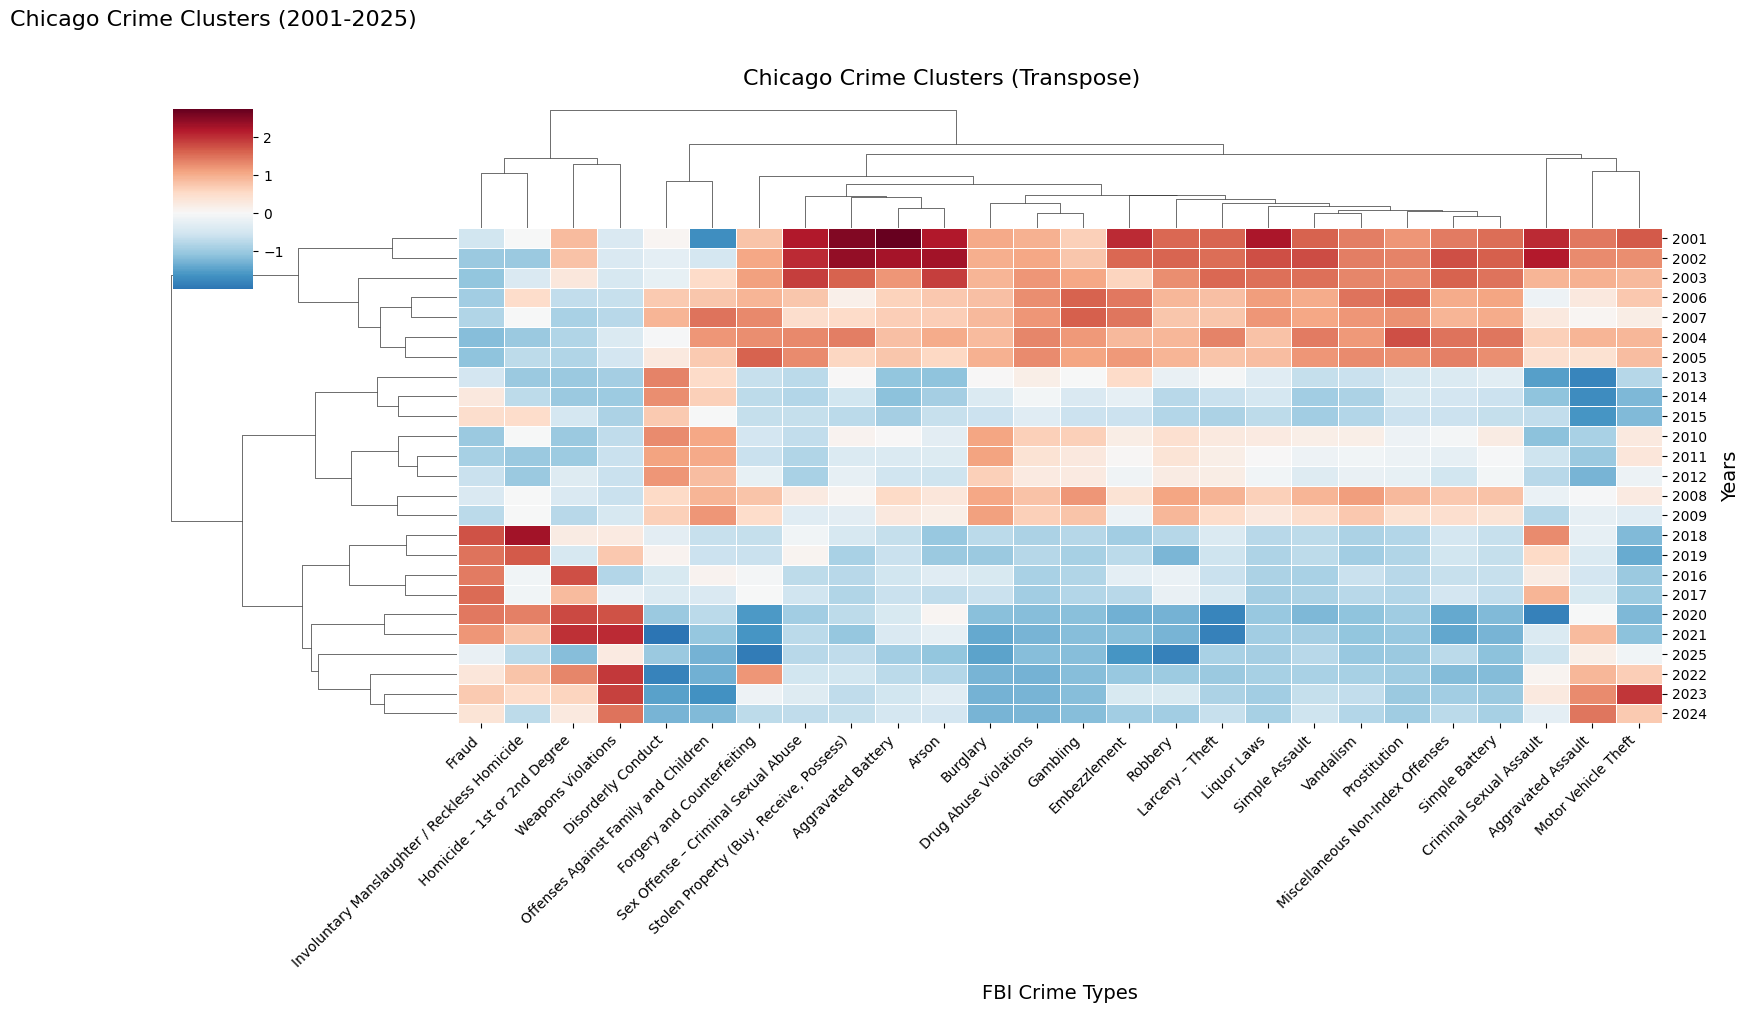

In [5]:
# Z score
z_df = zscore_anomaly.zscore_anomaly(data=df, time_col='year', category_col='fbi_code_desc')

# Create the clustermap
g = sns.clustermap(
    z_df.T, 
    cmap="RdBu_r", 
    center=0, 
    figsize=(16, 10),
    # row_cluster=True,  # Keep years in chronological order (on the Y-axis)
    col_cluster=True,  # Cluster the crimes together (on the X-axis)
    linewidths=0.5,
    xticklabels=True,   # Ensure all crime names show up
    yticklabels=True    # Ensure all years show up
)

# Rotate X-axis labels for readability
plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')
plt.title("Chicago Crime Clusters (2001-2025)", fontsize=16, pad=60)
plt.suptitle("Chicago Crime Clusters (Transpose)", fontsize=16, y=1.02)
g.ax_heatmap.set_xlabel('FBI Crime Types', fontsize=14, labelpad=10)
g.ax_heatmap.set_ylabel('Years', fontsize=14, labelpad=10)

# Save the figure with high resolution and tight cropping
plt.savefig("../Image/cluster_Heatmap_analysis.png", dpi=1200, bbox_inches='tight')
plt.show()

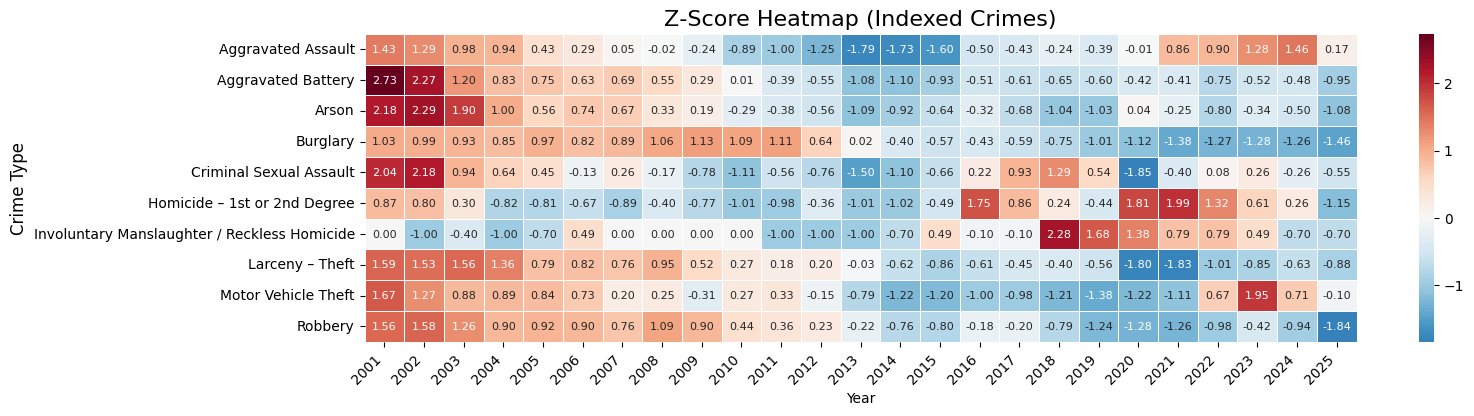

In [6]:
# Calculate z-scores Indexed Crime
df.fbi_index_code = df.fbi_index_code.astype('bool')
mask = df.fbi_index_code == True
z_df_i = zscore_anomaly.zscore_anomaly(data=df[mask], time_col='year', category_col='fbi_code_desc')
# plot
heat_map(z_df_i, 'Indexed', (16,4))

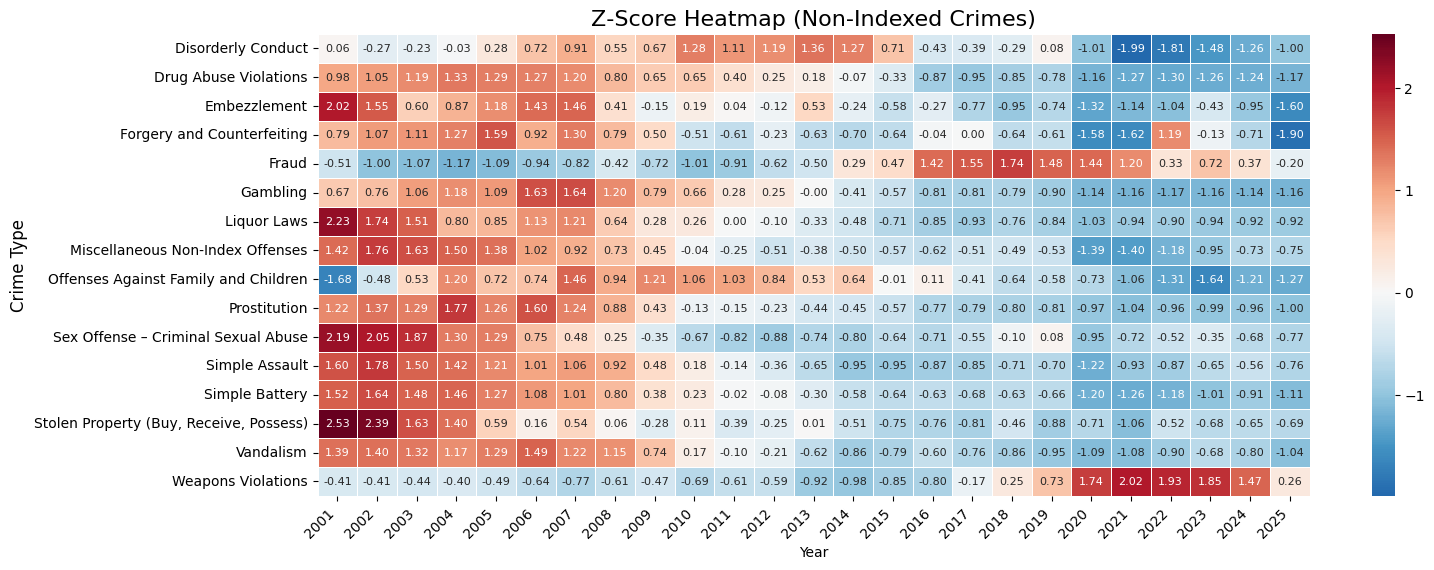

In [7]:
# Calculate z-scores Non-Indexed Crime
mask = df.fbi_index_code == False
z_df_n = zscore_anomaly.zscore_anomaly(data=df[mask],time_col='year', category_col='fbi_code_desc')
heat_map(z_df_n, 'Non-Indexed')

**Note:**
1. The Color Intensity (The Values)
* Since you are using Z-scores, look at the color first:
  - Deep Red: The crime count for that specific year was significantly above its historical average.
    - Deep Blue: The crime count for that specific year was significantly below its historical average.
    - White/Light Colors: The crime count was "normal" or very close to the 25-year mean.

2. The Dendrogram (The "Tree" Structure)
* The branches on the top (or side) tell you how similar items are.
* Close Neighbors: If two crime types are connected by a short "U-shaped" branch, they have very similar patterns over the 25-year period.
* Branch Length: The longer the vertical lines of the branch before they join, the less similar those two groups are.

3. Reading the "Clusters" (The Groups)
*  The "Legacy" Cluster: Crimes that were rampant in the early 2000s but have since crashed (like Drug Abuse Violations or Prostitution). These will be Red on the top-left and deep Blue on the bottom-right.
* The "Resilient" Cluster: Crimes that have stayed consistently high or "Red" for almost the entire 25 years. These are the persistent issues Chicago faces.
* The "Modern Surge" Cluster: Crimes that were blue for years but have recently turned bright Red (like Motor Vehicle Theft and Weapons Violations).

4. Reading the X and Y Axis Together
* To find a specific "Anomaly," look for a single "pop" of color that breaks a trend.
* Vertical Red Streaks: If you see a vertical column of red across many crimes for a single year (like 2020), it suggests an External Event (like the Pandemic or civil unrest) affected almost everything at once.
* Horizontal Red Streaks: If one crime type is red across many years, it shows a long-term sustained increase for that specific category.

5. Why the "Rotation" Helps
* By rotating the plot, you can now scan horizontally to see which crimes behave similarly in the same year, and scan vertically to see how a single crime's "fortune" has changed from 2001 to 2025.

**Tip: The "Pivot Point"**
* Look for where the colors flip from Blue to Red. In Chicago's data, there is often a "pivot" around 2016 and 2020. These are the years where the "old" patterns of crime significantly shifted into the "modern" patterns we see today.

### Clustering

In [8]:
z_df.head()

year,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
fbi_code_desc,,,,,,,,,,,,,,,,,,,,,,,,,
Aggravated Assault,1.426698,1.291884,0.980297,0.943692,0.428545,0.288375,0.054461,-0.021427,-0.244628,-0.889231,-0.997260,-1.250816,-1.790961,-1.729357,-1.601687,-0.500862,-0.429438,-0.242842,-0.386583,-0.008035,0.864232,0.899052,1.284742,1.456160,0.174989
Aggravated Battery,2.734977,2.265772,1.203024,0.832353,0.753761,0.627858,0.685336,0.548875,0.289640,0.012027,-0.390706,-0.545935,-1.082001,-1.104288,-0.931856,-0.514655,-0.608496,-0.651897,-0.603412,-0.422769,-0.411821,-0.745347,-0.515437,-0.477509,-0.947496
Arson,2.182703,2.288885,1.899550,1.004585,0.564687,0.741658,0.670870,0.327041,0.185465,-0.289827,-0.380840,-0.557811,-1.088722,-0.921864,-0.638712,-0.320165,-0.684218,-1.043215,-1.028046,0.043889,-0.249377,-0.795457,-0.335334,-0.497135,-1.078609
Burglary,1.034278,0.985417,0.927185,0.853082,0.970422,0.823091,0.889821,1.059770,1.128375,1.085263,1.110005,0.638146,0.019579,-0.395922,-0.568996,-0.430912,-0.591864,-0.748568,-1.011990,-1.121957,-1.384129,-1.267414,-1.281035,-1.260041,-1.461606
Criminal Sexual Assault,2.036762,2.178314,0.938319,0.638229,0.445719,-0.131813,0.264532,-0.165786,-0.782952,-1.105690,-0.562131,-0.760304,-1.496374,-1.100028,-0.664048,0.224898,0.926995,1.289368,0.541974,-1.847422,-0.397931,0.077684,0.264532,-0.262041,-0.550807


### Hierarchical Clustering Linkage Methods
* In hierarchical clustering, choosing the right linkage method is just as important as choosing the distance metric (like Euclidean or Manhattan). The linkage determines the "shape" of the clusters and the algorithm's sensitivity to outliers. These linkage methods work in practice; we need to examine the step-by-step logic of the Agglomerative (Bottom-Up) algorithm. This is the most common way hierarchical clustering is implemented.
* Agglomerative (Bottom-Up) Hierarchical Clustering is a widely used unsupervised machine learning algorithm that builds a nested hierarchy of clusters by iteratively merging the closest pairs of data points. Unlike k-means, it does not require specifying the number of clusters in advance, and the results are often visualized as a dendrogram. 
* `Linkage method choice:` The choice of linkage method in hierarchical clustering is a foundational decision that directly dictates how distances between clusters are calculated, which subsequently defines the structure and quality of the final clustering. 
    * cluster shape
    * sensitivity to noise
    * chaining vs. compactness
    * dendrogram height structure
    * number of clusters detected
#### 1. Specifying the Linkage Criterion: Linkage methods dictate how the algorithm decides which clusters to merge at each step.
[scipy.cluster.hierarchy.linkage](https://docs.scipy.org/doc/scipy/reference/generated/scipy.cluster.hierarchy.linkage.html)

#### 2. Specifying the Distance Metric: The distance metric defines the "proximity" between two single observations in your dataset.
[scipy.spatial.distance.cdist](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.distance.cdist.html)

##### Note:
* Distance = 0: This implies $r = 1$. The two categories are perfectly positively correlated. 
* Distance = 1: This implies $r = 0$. There is no linear relationship at all. These categories provide completely independent information.
* Distance = 2: This implies $r = -1$. They are perfectly negatively correlated. When one category spikes in Z-score, the other drops significantly.

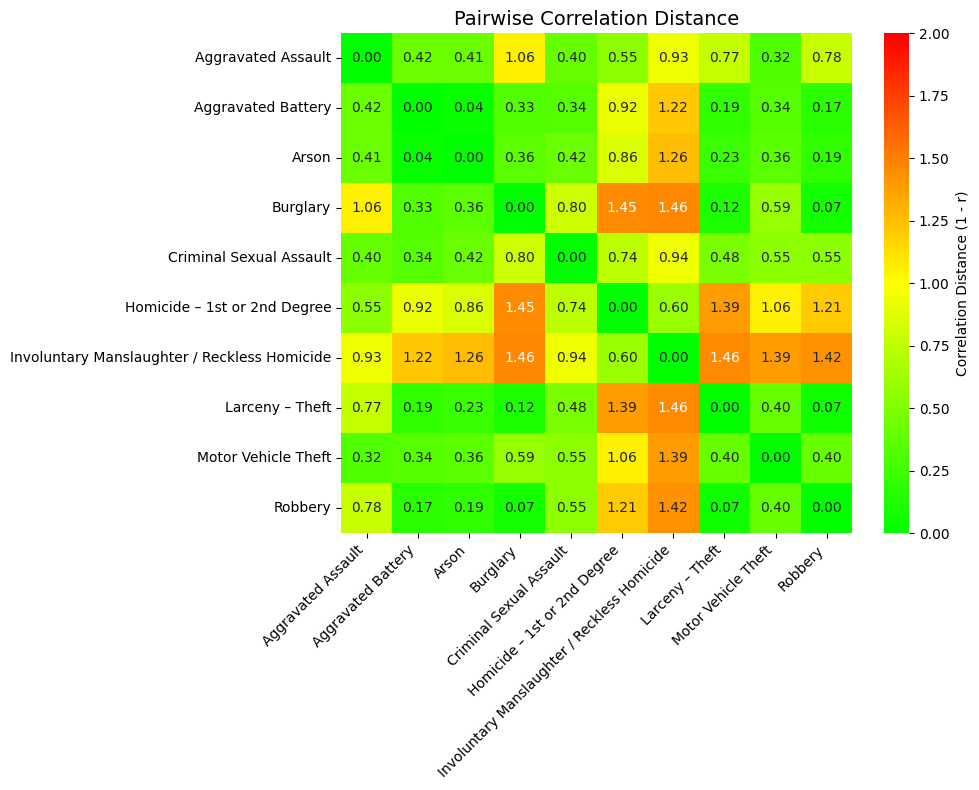

In [9]:
correlation_heatmap(z_df_i)

In [13]:
# Initialize Linkage variable
methods = ['single', 'complete', 'average']
metric = 'correlation'

for method in methods:
    Z_matrix = linkage_matrix(z_df_i, method, metric)
    # Linkage Matrix & Inconsistency coefficient matrix
    _ = hierarchy_clustering.choose_clusters_from_inconsistency(Z_matrix, method, metric)
    _ = hierarchy_clustering.choose_clusters_from_linkage(Z_matrix, method, metric)

----- Using Inconsistency coefficient Matrix ------
Method: single, Metric: correlation, Depth: 2
Estimated number of clusters: 5
Jump occurred at merge index 4

----- Using Linkage Matrix -----
Method: single, Metric: correlation
Estimated number of clusters: 3
Jump at merge index: 6

----- Using Inconsistency coefficient Matrix ------
Method: complete, Metric: correlation, Depth: 2
Estimated number of clusters: 6
Jump occurred at merge index 3

----- Using Linkage Matrix -----
Method: complete, Metric: correlation
Estimated number of clusters: 3
Jump at merge index: 6

----- Using Inconsistency coefficient Matrix ------
Method: average, Metric: correlation, Depth: 2
Estimated number of clusters: 5
Jump occurred at merge index 4

----- Using Linkage Matrix -----
Method: average, Metric: correlation
Estimated number of clusters: 5
Jump at merge index: 4



In [18]:
methods = ['ward', 'single', 'complete', 'average', 'median', 'centroid']
metric = 'euclidean'

for method in methods:
    Z_matrix = linkage_matrix(z_df_i, method, metric)
    # Linkage Matrix & Inconsistency coefficient matrix
    _ = hierarchy_clustering.choose_clusters_from_inconsistency(Z_matrix, method, metric)
    _ = hierarchy_clustering.choose_clusters_from_linkage(Z_matrix, method, metric)

----- Using Inconsistency coefficient Matrix ------
Method: ward, Metric: euclidean, Depth: 2
Estimated number of clusters: 4
Jump occurred at merge index 5

----- Using Linkage Matrix -----
Method: ward, Metric: euclidean
Estimated number of clusters: 3
Jump at merge index: 6

----- Using Inconsistency coefficient Matrix ------
Method: single, Metric: euclidean, Depth: 2
Estimated number of clusters: 8
Jump occurred at merge index 1

----- Using Linkage Matrix -----
Method: single, Metric: euclidean
Estimated number of clusters: 6
Jump at merge index: 3

----- Using Inconsistency coefficient Matrix ------
Method: complete, Metric: euclidean, Depth: 2
Estimated number of clusters: 6
Jump occurred at merge index 3

----- Using Linkage Matrix -----
Method: complete, Metric: euclidean
Estimated number of clusters: 3
Jump at merge index: 6

----- Using Inconsistency coefficient Matrix ------
Method: average, Metric: euclidean, Depth: 2
Estimated number of clusters: 8
Jump occurred at merge

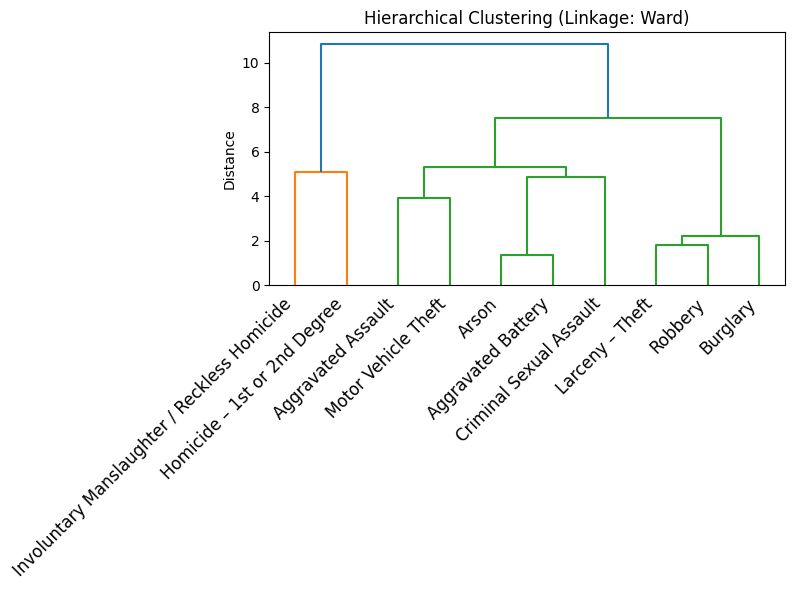

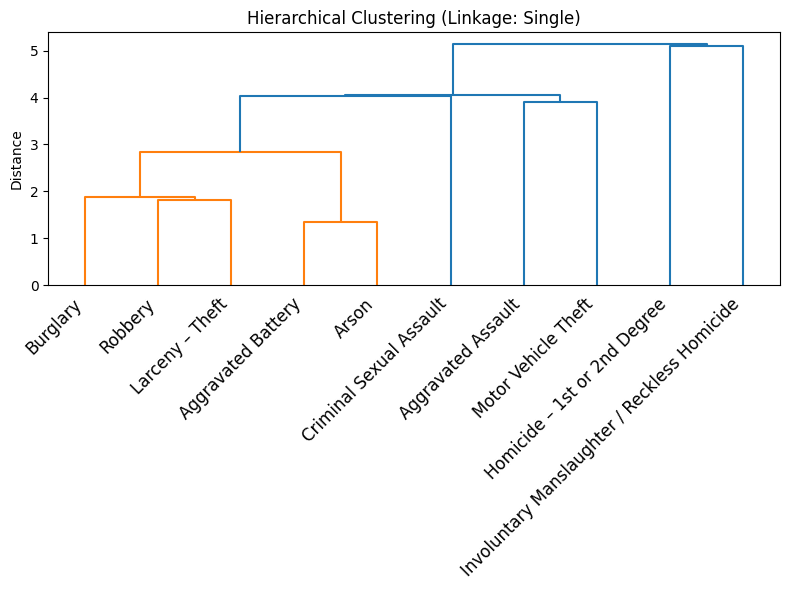

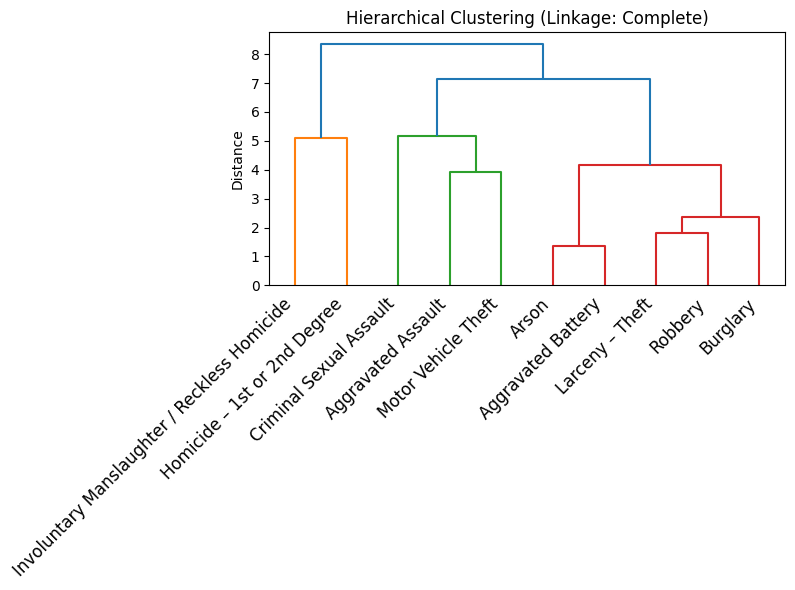

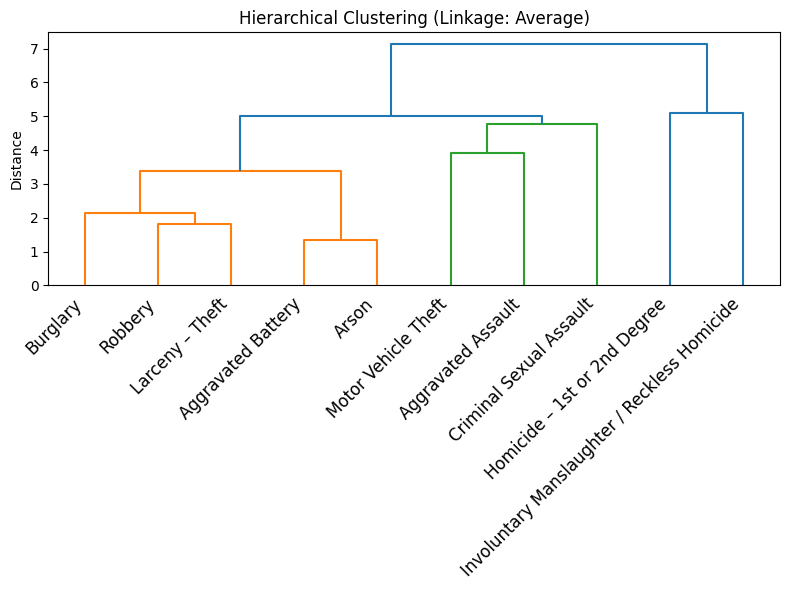

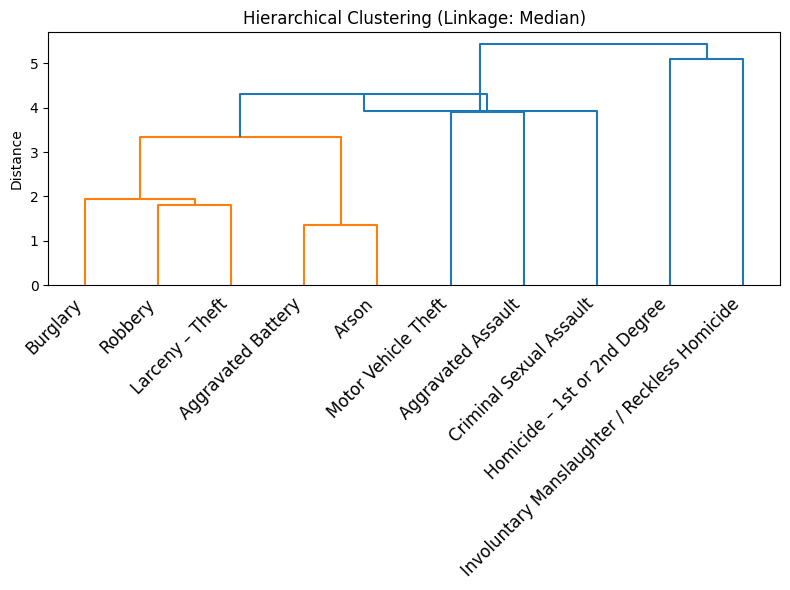

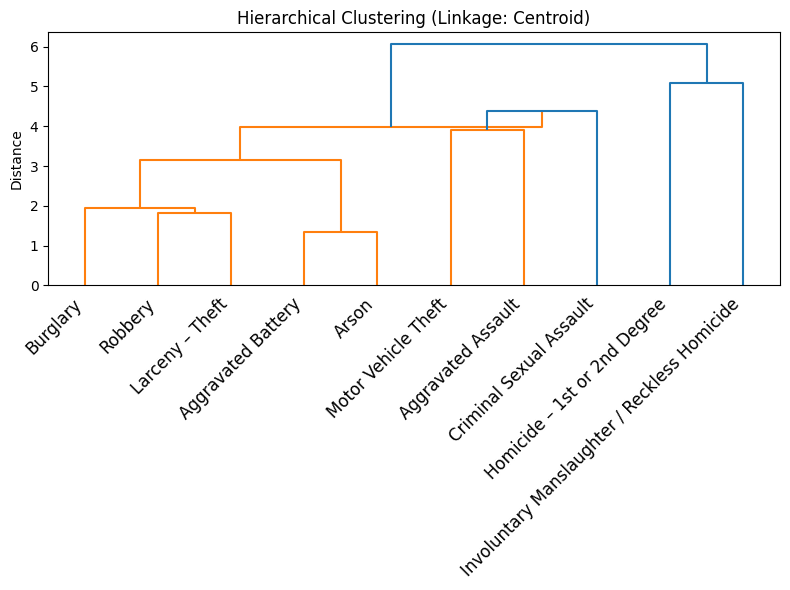

In [10]:
# Initialize Linkage variable
methods = ['ward', 'single', 'complete', 'average', 'median', 'centroid']
# Create Dict
Z_matrix = {}
# iterate
for method in methods:
    # Index Crime ONLY
    Z_matrix[method] =  plot_clustering(z_df_i,  method=method, metric='euclidean', figsize=(8,6), rotation=45)

## PCA

In [119]:
from sklearn.decomposition import PCA

# Transpose
data = z_df_i.T.copy()
columns = data.columns

# Initialize PCA
pca = PCA(n_components=0.95)
pca_data = pca.fit_transform(data)

print(f"Reduced {data.columns.shape[0]} categories down to {pca_data.shape[1]} components.")

Reduced 10 categories down to 5 components.


In [120]:
print(pca.explained_variance_ratio_)

[0.5578 0.2319 0.0827 0.0547 0.039 ]


In [121]:
# PCA loadings: rows = components, columns = original features
loadings = pd.DataFrame(pca.components_, columns=columns)

In [124]:
# Optional: show the contribution of each feature to each component
print("PCA Loadings (feature contributions to each component):")
loadings

PCA Loadings (feature contributions to each component):


fbi_code_desc,Aggravated Assault,Aggravated Battery,Arson,Burglary,Criminal Sexual Assault,Homicide – 1st or 2nd Degree,Involuntary Manslaughter / Reckless Homicide,Larceny – Theft,Motor Vehicle Theft,Robbery
0,0.219947,0.404516,0.393463,0.336354,0.270644,-0.045542,-0.154049,0.395935,0.326880,0.396705
1,0.497278,0.121664,0.131343,-0.358489,0.329073,0.559261,0.300371,-0.199969,0.115895,-0.165660
2,0.366719,-0.160874,-0.119992,-0.234052,-0.231021,-0.218289,-0.511005,-0.101221,0.603508,-0.183967
3,-0.078908,0.087787,0.291493,0.147125,-0.580900,0.596384,-0.341802,-0.195407,-0.097442,0.147742
4,0.211402,0.103040,0.095074,0.155585,-0.570999,-0.228059,0.680571,-0.067299,0.253556,0.037402


In [136]:
# To see the top contributors per component
top_n = 5  # change this to see more or fewer
for i, component in enumerate(loadings.values):
    sorted_idx = np.argsort(np.abs(component))[::-1]  # sort by absolute value
    top_features = data.columns[sorted_idx][:top_n]
    print(f"Top {top_n} contributors to PC{i+1}: {list(top_features)}")

Top 5 contributors to PC1: ['Aggravated Battery', 'Robbery', 'Larceny – Theft', 'Arson', 'Burglary']
Top 5 contributors to PC2: ['Homicide – 1st or 2nd Degree', 'Aggravated Assault', 'Burglary', 'Criminal Sexual Assault', 'Involuntary Manslaughter / Reckless Homicide']
Top 5 contributors to PC3: ['Motor Vehicle Theft', 'Involuntary Manslaughter / Reckless Homicide', 'Aggravated Assault', 'Burglary', 'Criminal Sexual Assault']
Top 5 contributors to PC4: ['Homicide – 1st or 2nd Degree', 'Criminal Sexual Assault', 'Involuntary Manslaughter / Reckless Homicide', 'Arson', 'Larceny – Theft']
Top 5 contributors to PC5: ['Involuntary Manslaughter / Reckless Homicide', 'Criminal Sexual Assault', 'Motor Vehicle Theft', 'Homicide – 1st or 2nd Degree', 'Aggravated Assault']


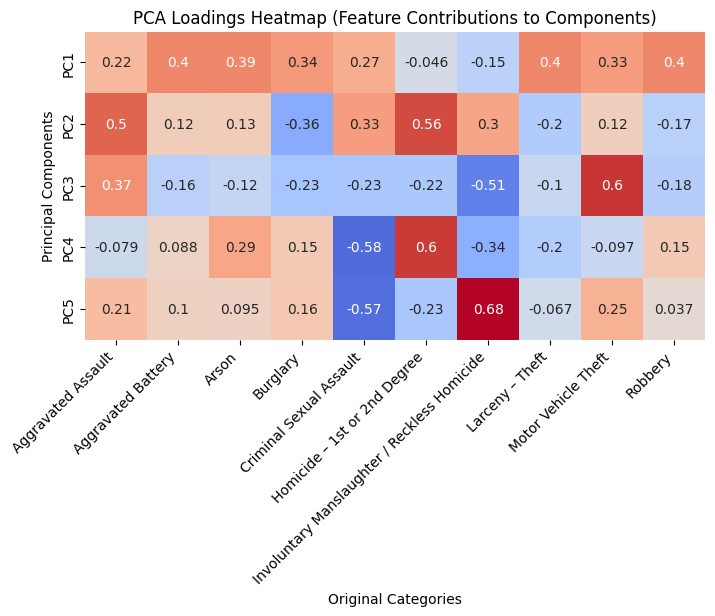

In [135]:
# Create a DataFrame for the loadings
loadings_df = pd.DataFrame(
    pca.components_, 
    columns=columns, 
    index=[f'PC{i+1}' for i in range(pca.components_.shape[0])]
)

# Plot heatmap
plt.figure(figsize=(8, 4))
sns.heatmap(
    loadings_df, 
    annot=True,        # show actual values
    cmap='coolwarm',   # red = negative, blue = positive
    cbar=False,
    center=0
)
plt.title('PCA Loadings Heatmap (Feature Contributions to Components)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Principal Components')
plt.xlabel('Original Categories')
plt.show()


In [20]:
# Get distance for 3 clusters
k = 4
# Distance threshold that yields exactly k clusters
idx = Z_matrix.shape[0] - (k - 1)
distance = int(Z_matrix[idx - 1, 2])
print(f"Distance: {distance}")

Distance: 4


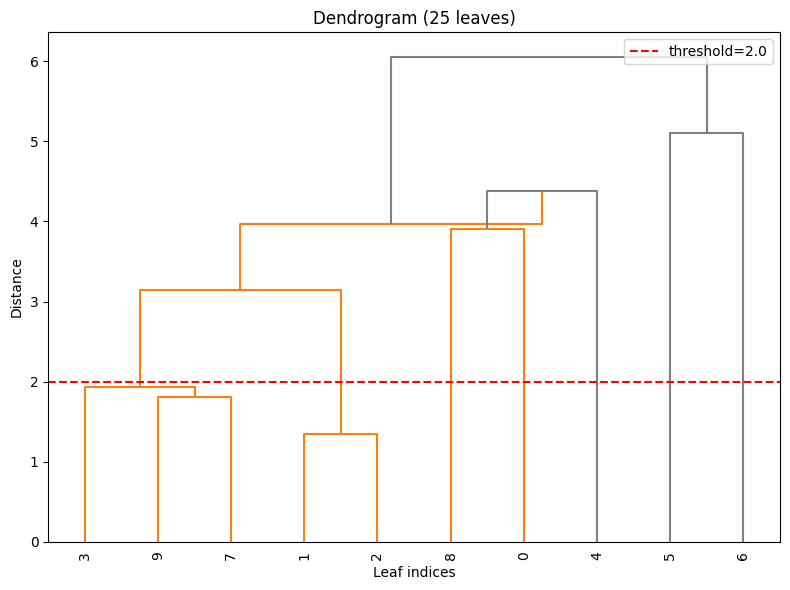

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
dn = hierarchy.dendrogram(Z_matrix, ax=ax, 
                         leaf_rotation=90, leaf_font_size=10,
                         color_threshold=distance, above_threshold_color='gray')
ax.set_title('Dendrogram (25 leaves)')
ax.set_xlabel('Leaf indices')
ax.set_ylabel('Distance')
ax.axhline(y=2.0, color='r', ls='--', label='threshold=2.0')
ax.legend()
plt.tight_layout()
plt.show()

In [28]:
# clusters = hierarchy.fcluster(z_df_i, t=distance, criterion='distance')
# print("Cluster sizes:", np.unique(clusters, return_counts=True))

In [25]:
z_df_i.index

Index(['Aggravated Assault', 'Aggravated Battery', 'Arson', 'Burglary',
       'Criminal Sexual Assault', 'Homicide – 1st or 2nd Degree',
       'Involuntary Manslaughter / Reckless Homicide', 'Larceny – Theft',
       'Motor Vehicle Theft', 'Robbery'],
      dtype='string[pyarrow]', name='fbi_code_desc')

In [27]:
# crime_groups = pd.DataFrame({
#     'fbi_code_desc': z_df_i.index, 
#     'cluster_id': clusters
# }).sort_values('cluster_id')

In [29]:
# # Create the mapping using .columns instead of .index
# # This matches the names on the X-axis of your rotated plot
# crime_groups = pd.DataFrame({
#     'fbi_code_desc': z_df.columns, 
#     'cluster_id': clusters
# }).sort_values('cluster_id')

# # Display the members
# for cluster_num in range(1, (len(np.unique(clusters))) + 1):
#     members = crime_groups[crime_groups['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
#     print(f"--- Cluster {cluster_num} & {distance} Distance Calculation value ---")
#     print("\n".join([f"  • {m}" for m in members]))
#     print("-" * 30)

In [30]:
# What is the difference between depth of 2 and 3?
I2 = hierarchy.inconsistent(Z_matrix, 2)
I3 = hierarchy.inconsistent(Z_matrix, 3)

print("Max inconsistency:")
print("depth=2:", I2[:,3].max())  
print("depth=3:", I3[:,3].max()) 

Max inconsistency:
depth=2: 1.092962237743695
depth=3: 1.4148858917298779


- Each row of the inconsistency matrix has four values:
    - Mean of the merge heights in the local neighborhood
    - Standard deviation of those heights
    - Number of links/merges used in the local neighborhood
    - Inconsistency coefficient : 
$
\text{inconsistency}_i = \frac{Z_{[i,2]} - \text{Local mean}}{\text{local Std}}
$


**The fourth column is the one that matters for evaluating cluster stability.**

- 0.0 $\rightarrow$ the merge height is identical to the local average $\rightarrow$ extremely natural merge
- 0.6 – 0.8 $\rightarrow$ mild deviation $\rightarrow$ still natural, but slightly broader merges
- 0.9 – 1.2 $\rightarrow$ noticeable deviation $\rightarrow$ the algorithm is merging groups that are less similar
- $\gt$ 2.0 (not present in your data) $\rightarrow$ strongly unnatural merges $\rightarrow$ forced merges across major cluster boundaries

Last 5 merges in Linkage Matrix (Z):
[[40.     44.      5.3435  4.    ]
 [42.     45.      6.0412  7.    ]
 [39.     43.      8.2901 15.    ]
 [47.     48.     10.4482 22.    ]
 [46.     49.     18.4716 26.    ]]

Last 5 rows in Inconsistency Matrix (I):
[Mean, Std Dev, Count, Inconsistency Coefficient]
[[ 4.4722  0.8127  3.      1.072 ]
 [ 4.9452  1.0688  3.      1.0254]
 [ 5.2432  2.6969  3.      1.1298]
 [ 8.2598  2.2037  3.      0.9931]
 [11.4211  6.6179  3.      1.0654]]


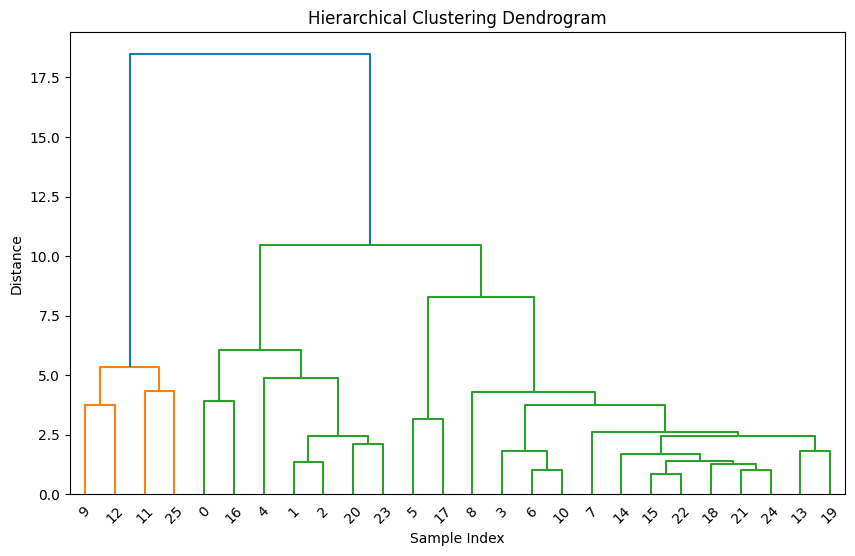

In [35]:
# from scipy.cluster.hierarchy import linkage, inconsistent, dendrogram

# linkage & inconsistent
Z_matrix = hierarchy.linkage(z_df, method='ward')
I_matrix = hierarchy.inconsistent(Z_matrix, d=2)

# Display the last 5 merges
print("Last 5 merges in Linkage Matrix (Z):")
print(Z_matrix[-5:])
print("\nLast 5 rows in Inconsistency Matrix (I):")
print("[Mean, Std Dev, Count, Inconsistency Coefficient]")
print(I_matrix[-5:])

# Visualize with a Dendrogram
plt.figure(figsize=(10, 6))
hierarchy.dendrogram(Z_matrix)
plt.title('Hierarchical Clustering Dendrogram')
plt.xlabel('Sample Index')
plt.ylabel('Distance')
plt.show()

## Determine Number of Cluster

In [36]:
# Last 10 merges (closest to the root)
print("Last 10 inconsistency coefficients:")
print(I_matrix[-10:, -1])


Last 10 inconsistency coefficients:
[1.0561 0.     0.7071 0.     0.7071 1.072  1.0254 1.1298 0.9931 1.0654]


In [38]:
# inconsistency coefficients only go up to approximately 1.13
for t in np.linspace(0.1, 1.2, 12):
    labels = hierarchy.fcluster(Z_matrix, t, criterion='inconsistent')
    print(f"t={t:.2f} -> {len(np.unique(labels))} clusters")

t=0.10 -> 16 clusters
t=0.20 -> 16 clusters
t=0.30 -> 16 clusters
t=0.40 -> 16 clusters
t=0.50 -> 16 clusters
t=0.60 -> 16 clusters
t=0.70 -> 16 clusters
t=0.80 -> 12 clusters
t=0.90 -> 10 clusters
t=1.00 -> 10 clusters
t=1.10 -> 8 clusters
t=1.20 -> 1 clusters


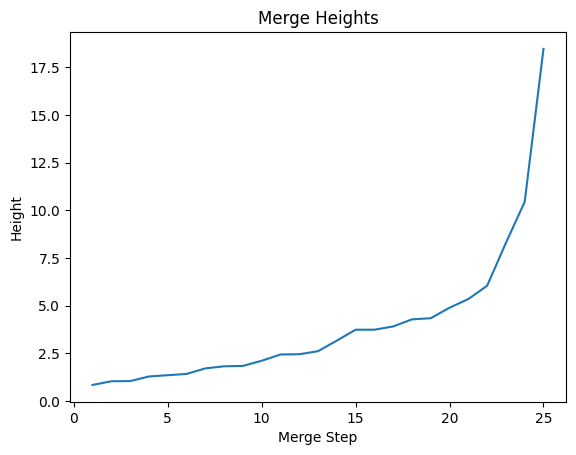

In [39]:
heights = Z_matrix[:, 2]
plt.plot(range(1, len(heights)+1), heights)
plt.title("Merge Heights")
plt.xlabel("Merge Step")
plt.ylabel("Height")
plt.show()

In [40]:
# display last 10 merge heights directly
print(Z_matrix[-10:, 2])

[ 3.7348  3.9058  4.2771  4.3386  4.8887  5.3435  6.0412  8.2901 10.4482 18.4716]


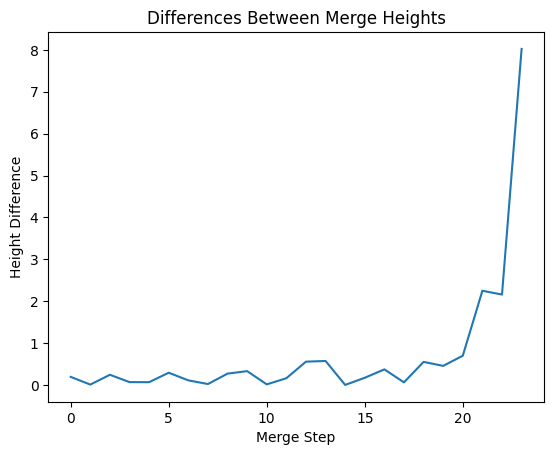

In [41]:
heights = Z_matrix[:, 2]
diffs = np.diff(heights)

plt.plot(diffs)
plt.title("Differences Between Merge Heights")
plt.xlabel("Merge Step")
plt.ylabel("Height Difference")
plt.show()


In [43]:
# # Use the transposed DataFrame you used for the plot
# # This ensures we are looking at the 26 crime types (columns)


# # clusters = fcluster(linkage, t=distance_threshold, criterion='distance')
# # clusters = fcluster(linkage, t=distance, criterion='distance')


# # Create the mapping using .columns instead of .index
# # This matches the names on the X-axis of your rotated plot
# crime_groups = pd.DataFrame({
#     'fbi_code_desc': z_df.T.columns, 
#     'cluster_id': clusters
# }).sort_values('cluster_id')

# # Display the members
# for cluster_num in range(1, (len(np.unique(clusters))) + 1):
#     members = crime_groups[crime_groups['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
#     print(f"--- Cluster {cluster_num} & {distance} Distance Calculation value ---")
#     print("\n".join([f"  • {m}" for m in members]))
#     print("-" * 30)


In [45]:
# # cuts
# cuts = distance.copy()
# # generate the cluster labels at each cut height
# labels = {h: fcluster(Z, t=h, criterion='distance') for h in cuts}

# # clusters at each height
# print("Clusters @ each hight:" ,{k: len(set(v)) for k, v in labels.items()})

# def similarity(a, b):
#     return np.mean(a == b)

# # score
# similarity(labels[3.2], labels[4.3]), similarity(labels[4.3], labels[4.8])

In [47]:
# # generate the cluster labels at each cut height
# labels = {h: fcluster(Z, t=h, criterion='distance') for h in cuts}
# labels

In [49]:
from sklearn.metrics import silhouette_score

# Silhouette score (cluster quality)
scores = {h: silhouette_score(z_score.T, labels[h]) for h in labels}
scores

**Silhouette score for hierarchical clustering on standardized temporal profiles:**
- 0.20–0.30 $\rightarrow$ weak but usable
- 0.30–0.40 $\rightarrow$ moderate, interpretable structure
- 0.40+ $\rightarrow$ strong, rarely seen in noisy real‑world time series

In [ ]:
# Create a list to store dataframes with their threshold ID
centroid_list = []

for h, lab in labels.items():
    # Ensure we are working with Crime as Rows, Years as Columns
    # If your z_score is already (Crimes x Years), don't use .T
    df_tmp = z_score.T.copy() 
    df_tmp['cluster'] = lab
    
    # Calculate means and add the threshold 'h' as a column
    mean_df = df_tmp.groupby('cluster').mean().assign(threshold=h)
    centroid_list.append(mean_df)

# Concatenate into one master DataFrame
df_centroids = pd.concat(centroid_list).reset_index()

# View the result
mask = df_centroids.threshold == 3.2
df_centroids.loc[mask]

# # Inspect cluster centroids
# centroids = {}
# for h, lab in labels.items():
#     df_tmp = pd.DataFrame(z_score.T)
#     df_tmp['cluster'] = lab
#     centroids[h] = df_tmp.groupby('cluster').mean()
# centroids

#### Tranpost Z-Scores

In [ ]:
# Raw Tranpost linkage matrix, and this matrix tells the entire story of your dendrogram’s structure
Z_t = g_t.dendrogram_col.linkage

# Inconsistency coefficient column
I_t = inconsistent(Z_t, 2)   # depth=2 is the standard choice

In [ ]:
# Inspect inconsistency
heights_t = Z_t[:, 2] 
incons_t = I_t[:, 3]

print(heights_t) 
print(incons_t)

In [ ]:
# Find merges with higher inconsistency,
idx_high_t = np.where(incons_t > 1.0)[0]
critical_heights_t = heights_t[idx_high_t]
# Critical_heights are where merges start to be “stretched”.
critical_heights_t

In [ ]:
plot.plot_cuts(heights_t, incons_t)

In [ ]:
# Test these
cuts_t = [2.0, 2.5, 3.3]
# generate the cluster labels at each cut height
labels_t = {h: fcluster(Z_t, t=h, criterion='distance') for h in cuts_t}

for h in cuts_t:
    n_clus = len(set(fcluster(Z_t, t=h, criterion='distance')))
    print(f"h={h}: {n_clus} clusters")

# score
similarity(labels_t[2.0], labels_t[2.5]), similarity(labels_t[2.5], labels_t[3.3])

In [ ]:
# Silhouette score (cluster quality)
scores = {h: silhouette_score(z_score, labels_t[h]) for h in labels_t}
scores

In [ ]:
# Use the transposed DataFrame you used for the plot
# This ensures we are looking at the 26 crime types (columns)
for h in cuts_t:
    # Get the linkage and clusters
    linkage = g_t.dendrogram_col.linkage 
    # clusters = fcluster(linkage, t=distance_threshold, criterion='distance')
    clusters_t = fcluster(linkage, t=h, criterion='distance')
    
    # Create the mapping using .columns instead of .index
    # This matches the names on the X-axis of your rotated plot
    crime_groups_t = pd.DataFrame({
        'fbi_code_desc': z_score.T.columns, 
        'cluster_id': clusters_t
    }).sort_values('cluster_id')
    
    # Display the members
    for cluster_num in range(1, (len(np.unique(clusters_t))) + 1):
        members = crime_groups_t[crime_groups_t['cluster_id'] == cluster_num]['fbi_code_desc'].tolist()
        print(f"--- Cluster {cluster_num} & {h} Distance Calculation value ---")
        print("\n".join([f"  • {m}" for m in members]))
        print("-" * 30)
    print("\n")

In [ ]:
a = np.array([1,2, 3])
b = np.array([4, 5, 6])

In [ ]:
a.dot(b.T), a*b.T